In this lesson, we will read the data we saved in lesson 2 and implement the next analysis step: 
Identifying stars with the proper motion we expect for GD-1

In [1]:
import sys
from os.path import basename, exists
from astropy.table import Table
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import GD1Koposov10
import pandas as pd

# Reloading the data

In [2]:
filename = "gd1_results.fits"
results = Table.read(filename)
results

source_id,ra,dec,pmra,pmdec,parallax
,deg,deg,mas / yr,mas / yr,mas
int64,float64,float64,float64,float64,float64
638249388774300416,141.93501729008403,22.167425792262385,-2.17839421955861,-2.5827521874347372,0.0956975204679928
638249526213253504,141.9753061718924,22.166906644614826,-0.3889177192090745,-4.890311960561159,0.9107815912221747
638042856682365312,142.60877152027857,21.933600782473206,4.987996623662445,-11.380074631444181,0.1413405186597264
638330305958410880,141.86014647492885,22.689263869886823,-2.55747137703185,-7.793223860816508,0.29564149985564947
638247808226333824,142.06685526516077,22.153802356111232,-4.1512710258404795,-5.535636228952605,0.37008934654368597
638040962601437952,142.43297107446548,21.949791707499113,6.308063008030676,-19.457292257225994,0.3953942905076676
638021721148028032,142.7734865975511,22.031287699030067,-0.7365007630038489,-9.83637724415779,0.7548992385125219
638057798874006272,142.22333117472294,22.064087673223725,1.8821275481141129,-1.405879770731665,0.5499980977288826


# Selecting rows and columns

In [3]:
# We can return the column names using colnames
results.colnames

['source_id', 'ra', 'dec', 'pmra', 'pmdec', 'parallax']

In [4]:
# We can select an individual column like in pandas which returns
#  a Column object
results["ra"]

141.93501729008403
141.9753061718924
142.60877152027857
141.86014647492885
142.06685526516077
142.43297107446548
142.7734865975511
142.22333117472294
143.21984737101306
143.19089441757134
141.75577187368566


The rows in the Table object are indexed from 0 to n-1 

In [5]:
# We can select the first row at index 0 to return a Row object
results[0]

source_id,ra,dec,pmra,pmdec,parallax
,deg,deg,mas / yr,mas / yr,mas
int64,float64,float64,float64,float64,float64
638249388774300416,141.93501729008403,22.167425792262385,-2.17839421955861,-2.5827521874347372,0.0956975204679928


In [6]:
# We can select a an element from a column by applying the 
#  bracket operator twice (selecting either row or column first)
print(results["ra"][0])
print(results[0]["ra"])

141.93501729008403
141.93501729008403


# Scatter plot

To see the results, we'll use a scatterplot

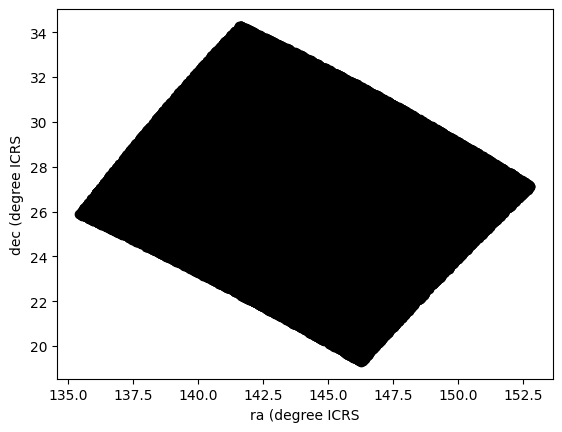

In [7]:
%matplotlib inline
x = results["ra"]
y = results["dec"]
plt.plot(x, y, "ko") # ko is for black, round marker

plt.xlabel("ra (degree ICRS")
plt.ylabel("dec (degree ICRS")
plt.show()

This plot shows the region we selected with the query in the previous lesson

We can see that the region we slected (a rectngle in the GD-1 coordinates) is a non-rectangular region in ICRS coordinates

But there are so many overlapping data points that we cannot distinguish between high and low density areas

To fix this we can provide optional arguments to control the size and transparency of the points

# Excercise
In the call to plt.plot, use the keyword argument markersize to make the markers smaller.

Then add the keyword argument alpha to make the markers partly transparent.

Adjust these arguments until you think the figure shows the data most clearly.

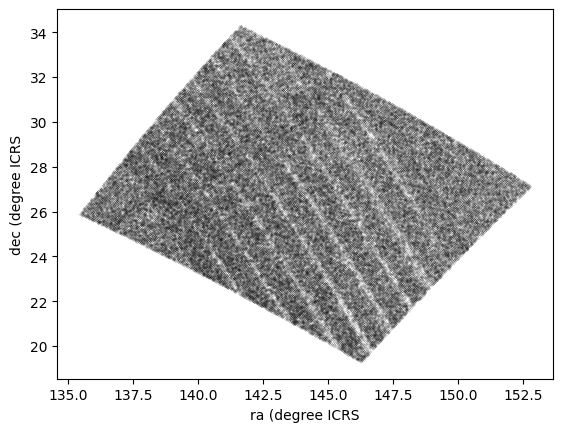

In [8]:
%matplotlib inline
x = results["ra"]
y = results["dec"]
plt.plot(x, y, "ko", markersize=0.15, alpha=0.4) # ko is for black, round marker

plt.xlabel("ra (degree ICRS")
plt.ylabel("dec (degree ICRS")
plt.show()

The figure now shows stripes with lower density of stars, which are caused by the way that Gaia scans the sky

Gaia data release 2 covers 22 months of observations, some parts of the sky were scanned more than others during this period

# Transform back
We selected data in the GD1-frame, then transformed them to ICRS when we constructed the query, the results table above is in ICRS

To plot them we need ton transform them back into the GD-1 frame, then the axes of the figure will be alligned with the orbit of GD-1 

transforming the coordinates is useful for two reasons:
 1) We can identify stars that are likely to be in GD-1 by  selecting stars near the centerline of the stream (where phi2 is close to 0)
 2) By transforming the proper motions, we can identify stars with non-zero proper motion along the phi1 axis

To do the transformation, we'll put the results into a SkyCoord object 

In [9]:
distance = 8 * u.kpc
radial_velocity = 0 * u.km/u.s

skycoord = SkyCoord(ra=results["ra"],
                    dec = results["dec"],
                    pm_ra_cosdec = results["pmra"],
                    pm_dec = results["pmdec"],
                    distance = distance,
                    radial_velocity = radial_velocity)

In [10]:
# Transform to GD-1 frame
gd1_frame = GD1Koposov10.GD1Koposov10()
transformed = skycoord.transform_to(gd1_frame)

# Reflex correction 

We now need to correct the proper motion measurements for the effct of the motion of our solar system around the galactic center

When creating skycoord, we provided constant values for distance and radial_velocity rather than measurement from Gaia. We can do this because the stars in GD-1 are so far away that the distance estimates from Gaia are no that accurate (they are based on parallax), so we replace them with the current best estiamte of the mean distance to GD-1 (~ 8kpc)

Distance estiamtes for other stars in the table will be inaccurate, so reflex correction will not be accurate, This however should only have a small effect on our ability to identify stars with the proper motion we expect for GD-1

The measurement on radial velocity has no effect on the correction for proper motion, but we have to provide a value to avoid errors in the reflex correction calcultion (we therefore provide 0 as an arbitrary palce-keeper) 

In [11]:
# We can use reflex_correction from Gala to correct for the motion
# of the solar system

# normally inported from the gala package, but we are still having 
# issues with installing gala. We therefore create a python file 
# with the reflex_correct function and import that file

import reflex_correct
skycoord_gd1 = reflex_correct.reflex_correct(transformed)

The result is a SkyCoord object that contains:
 1) phi1 and phi2, which represent the transformed coordinates in the GD-1 frame
 2) pm_phi1_cosphi2 and pm_phi2, which represent the transformed and corrected proper motions

Text(0, 0.5, 'phi2 (degree GD1)')

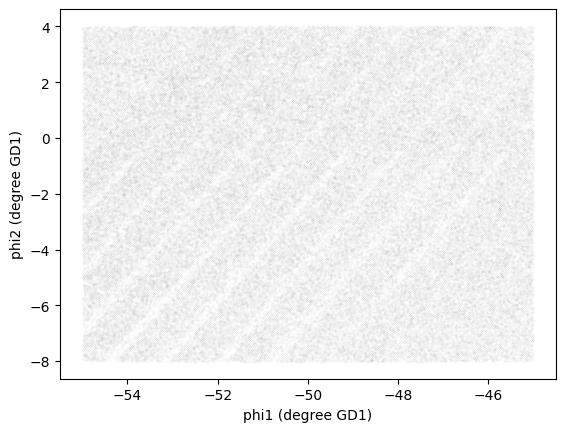

In [12]:
# Let's now select and plot the coordinates

x = skycoord_gd1.phi1
y = skycoord_gd1.phi2
plt.plot(x, y, "ko", markersize=0.1, alpha=0.1)

plt.xlabel("phi1 (degree GD1)")
plt.ylabel("phi2 (degree GD1)")

# Pandas dataframe

At this point we have two objects containing different subsets of data:
 1) results - the Astropy Table we downloaded from Gaia
 2) skycoord_gd1 - a SkyCoord object that contains the transformed coordinates and proper motions

Working with multiple datasets can be difficult, we can combine both subsets into one pandas dataframe
 - There is one drawback though, a pandas dataframe does not keep the metadata associated with the table (including units for each column)

In [13]:
results_df = results.to_pandas()
results_df

,source_id,ra,dec,pmra,pmdec,parallax
0,638249388774300416,141.935017,22.167426,-2.178394,-2.582752,0.095698
1,638249526213253504,141.975306,22.166907,-0.388918,-4.890312,0.910782
2,638042856682365312,142.608772,21.933601,4.987997,-11.380075,0.141341
3,638330305958410880,141.860146,22.689264,-2.557471,-7.793224,0.295641
4,638247808226333824,142.066855,22.153802,-4.151271,-5.535636,0.370089
...,...,...,...,...,...,...
140334,634696488748234752,144.017233,20.891631,-7.250549,2.759921,-0.177475
140335,634907732419474560,143.678987,21.231842,0.914603,-16.142584,0.665181
140336,634990023993097344,143.252378,21.554585,5.740627,-4.046934,0.887654
140337,634935430663403904,143.793845,21.600562,-2.193448,7.490876,-0.287731


We can now extract the columns we want from skycoord_gd1 and add them as columns into the dataframe

phi1 and phi2 contain the transformed coordinates

In [14]:
results_df['phi1'] = skycoord_gd1.phi1
results_df['phi2'] = skycoord_gd1.phi2
results_df.shape

(140339, 8)

pm_phi1_cosphi2 and pm_phi2 contain the components of proper motion in the transformed coordinates 

In [15]:
results_df['pm_phi1'] = skycoord_gd1.pm_phi1_cosphi2
results_df['pm_phi2'] = skycoord_gd1.pm_phi2
results_df.shape

(140339, 10)

In [16]:
results_df

,source_id,ra,dec,pmra,pmdec,parallax,phi1,phi2,pm_phi1,pm_phi2
0,638249388774300416,141.935017,22.167426,-2.178394,-2.582752,0.095698,-54.920042,-3.008902,2.048227,3.178359
1,638249526213253504,141.975306,22.166907,-0.388918,-4.890312,0.910782,-54.899632,-3.040158,1.132270,0.403763
2,638042856682365312,142.608772,21.933601,4.987997,-11.380075,0.141341,-54.764111,-3.657288,-1.203565,-7.731138
3,638330305958410880,141.860146,22.689264,-2.557471,-7.793224,0.295641,-54.524981,-2.660457,-2.474251,0.603602
4,638247808226333824,142.066855,22.153802,-4.151271,-5.535636,0.370089,-54.863124,-3.117821,-1.501332,3.158793
...,...,...,...,...,...,...,...,...,...,...
140334,634696488748234752,144.017233,20.891631,-7.250549,2.759921,-0.177475,-54.883020,-5.327895,3.554469,10.251804
140335,634907732419474560,143.678987,21.231842,0.914603,-16.142584,0.665181,-54.781880,-4.874873,-7.364718,-7.170778
140336,634990023993097344,143.252378,21.554585,5.740627,-4.046934,0.887654,-54.740531,-4.364732,5.317358,-4.264665
140337,634935430663403904,143.793845,21.600562,-2.193448,7.490876,-0.287731,-54.416339,-4.753592,10.342914,8.806617


# Exploring data

One of the most useful functions of pandas dataframes is the describe function, which computes summary statistics for each column

# Plot proper motion

We can now replicate one of the panels in Figure 1 from the paper, the plot that shows components of proper motion as a scatter plot

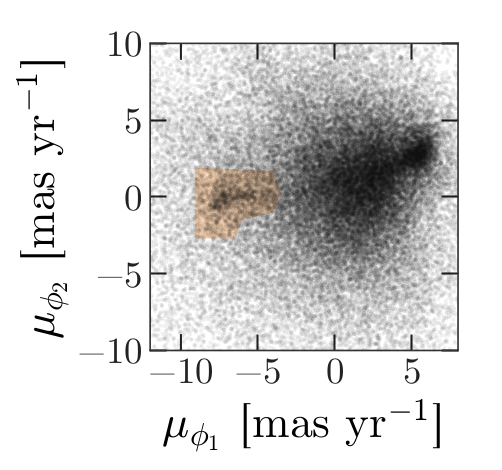

In [17]:
from IPython.display import Image
Image(filename='gd1-1.png')

The shaded area identifies stars that are likely to be in GD-1:
1) We expect the proper motions for stars in GD-1 to be along the axis of the stream (we expect motion in the direction of phi2 to be near 0)
2) In the direction of phi1 we don't have a prior expectation of proper motion, except that it should form a cluster at a non-zero value

(-10.0, 10.0)

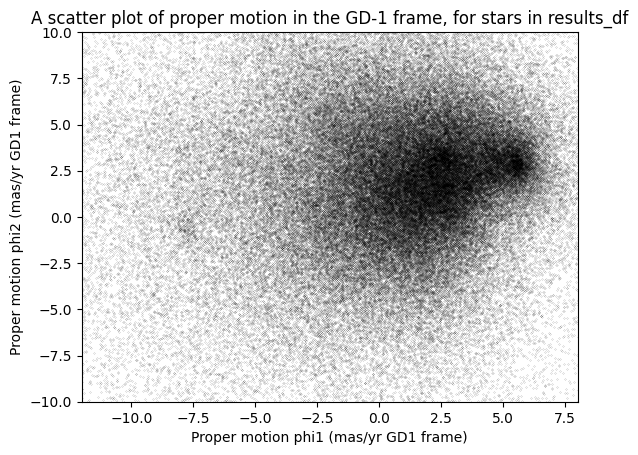

In [18]:
x = results_df["pm_phi1"]
y = results_df["pm_phi2"]

plt.plot(x, y, "ko", markersize=0.1, alpha=0.8)

plt.xlabel("Proper motion phi1 (mas/yr GD1 frame)")
plt.ylabel("Proper motion phi2 (mas/yr GD1 frame)")

plt.title("A scatter plot of proper motion in the GD-1 frame, for stars in results_df")

plt.xlim(-12,8)
plt.ylim(-10,10)

There is a hint of an overdense region near (-7.5, 0)

To see the cluster more clearly we need a sample that contains a higher proportion of stars in GD-1, we can do that be slelecting stars close to the centerline


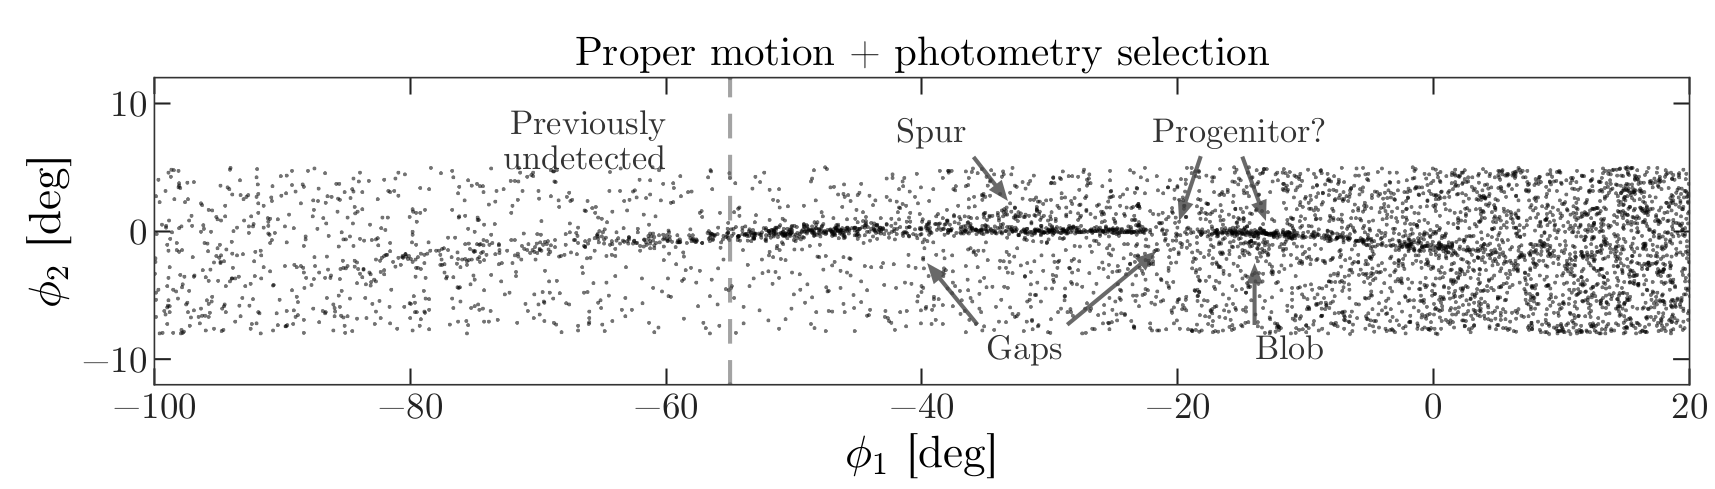

In [19]:
Image(filename='gd1-4.png')

Many stars in the figure above are less than 1 degree from phi2=0. Stars near this line have the highest probability of being in GD-1

To select them we will use a boolean mask

In [20]:
phi2 = results_df["phi2"]
phi2_min = -1 *u.degree
phi2_max = 1 *u.degree

# We can use a comparisson operator to compare the 
# values in a pandas Series object to a constant 

mask = (phi2 > phi2_min) & (phi2 < phi2_max)
mask.head() # returns a pandas Series object of 
# boolean values 

0    False
1    False
2    False
3    False
4    False
Name: phi2, dtype: bool

In [21]:
# Use sum to see how many stars are in the 
# selected region
mask.sum()

np.int64(25084)

In [22]:
# We can use a boolean series to "mask out" some of the 
# rows in a dataframe and select the rest
centerline_df = results_df[mask]
centerline_df.head() # Contains only stars near the 
# centerline of GD-1

,source_id,ra,dec,pmra,pmdec,parallax,phi1,phi2,pm_phi1,pm_phi2
106,687399143380060544,139.570971,23.776423,-2.783221,-8.228366,0.595185,-54.776890,-0.306076,-3.005469,0.768529
107,687376053635885696,139.353050,23.647826,-5.991404,-12.944900,0.854794,-54.993299,-0.208530,-8.719284,0.917799
108,687404877160366976,139.526420,23.887267,-1.475456,-30.185579,0.587460,-54.706073,-0.211566,-20.715182,-12.268763
109,687395118994649984,139.243311,23.857752,-4.876327,-6.059835,-1.195874,-54.871486,-0.010238,-2.327218,3.733363
110,687404155605847168,139.557029,23.866703,-0.261900,-7.018585,-0.341692,-54.708095,-0.246238,-0.616065,-0.685287


In [23]:
print(f"Total number of stars near the centerline: {len(centerline_df)}")

# What fraction of the rows we've selected 
print(f"Fraction of total data: {len(centerline_df) / len(results_df)}")

Total number of stars near the centerline: 25084
Fraction of total data: 0.1787386257562046


# plotting proper motion

We shall make a function to plot the proper motion to reduce repeated code

In [24]:
def plot_proper_motion(df):
    """
    plot proper motion.

    df: DataFrame with 'pm_phi1' and 'pm_phi2'
    """

    x = df["pm_phi1"]
    y = df["pm_phi2"]

    plt.plot(x, y, "ko", markersize=0.3, alpha=0.5)
    plt.xlabel('Proper motion phi1 (mas/yr GD1 frame)')
    plt.ylabel('Proper motion phi2 (mas/yr GD1 frame)')

    plt.xlim(-12, 8)
    plt.ylim(-10, 10)

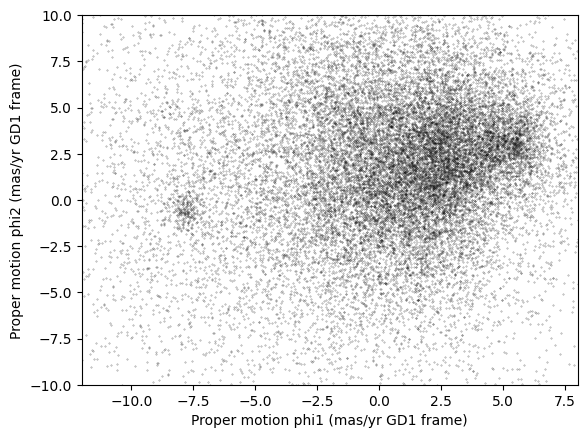

In [25]:
plot_proper_motion(centerline_df)

We can now clearly see that there is a cluster near (-7.5, 0)

# Filtering based on proper motion 

The next step is to select stars in the "overdense" region of proper motion, which are candidates to be in GD-1

We shall use a simple rectangle for now 

In [26]:
pm1_min = -8.9
pm1_max = -6.9
pm2_min = -2.2
pm2_max = 1.0

In [27]:
def make_rectangle(x1,x2,y1,y2):
    """
    Returns the corners of a rectangle 
    """
    xs = [x1, x1, x2, x2, x1]
    ys = [y1, y2, y2, y1, y1]
    return xs, ys

In [28]:
pm1_rect, pm2_rect = make_rectangle(
    pm1_min, pm1_max, pm2_min, pm2_max)

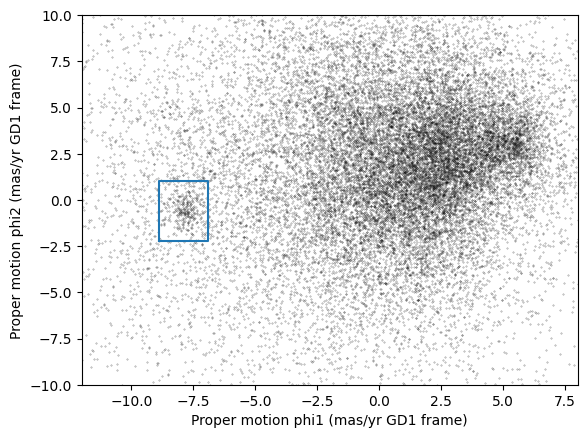

In [29]:
plot_proper_motion(centerline_df)
plt.plot(pm1_rect, pm2_rect)

Now that we've identified the bounds of the cluster in proper motion, we can use it to select rows fdrom 

In [30]:
def between(series, low, high):
    """ 
    Uses pandas operators to make a mask that selects 
    rows where 'series' falls between 'low' 
    and 'high'
    """
    return (series > low) & (series < high)

In [31]:
# Making a mask that selects stars with proper motion 
#  in the region we chose

pm1 = results_df['pm_phi1']
pm2 = results_df['pm_phi2']

pm_mask = (between(pm1, pm1_min* u.mas / u.yr, pm1_max* u.mas / u.yr) & 
           between(pm2, pm2_min* u.mas / u.yr, pm2_max* u.mas / u.yr))

In [32]:
pm_mask.sum()

np.int64(1049)

In [33]:
selected_df = results_df[pm_mask]
len(selected_df)

1049

These are the stars we think are likely to be in GD-1

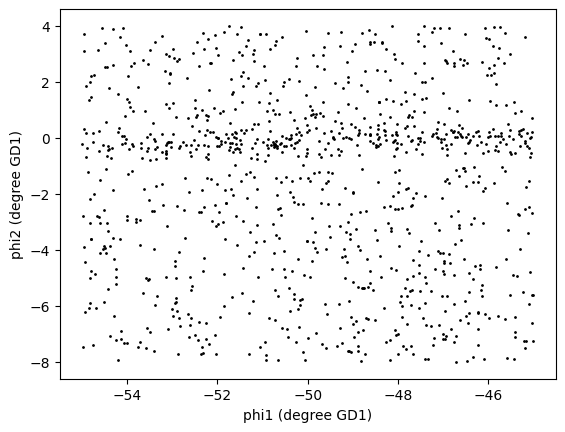

In [34]:
x = selected_df['phi1']
y = selected_df['phi2']
plt.plot(x, y, 'ko', markersize=1, alpha=1)

plt.xlabel('phi1 (degree GD1)')
plt.ylabel('phi2 (degree GD1)');

# Saving the dataframe 

To save a pandas DataFrame, one option is to convert it to an Astropy Table

In [35]:
selected_table = Table.from_pandas(selected_df)
type(selected_table)

astropy.table.table.Table

We could write the Astropy Table to a FITS format, but pandas provides functions to write DataFrames in other formats

One of the best options is version 5 of the Hierarchical Data Format (HDF5), which is a binary format meaning that files are small and fast to read and write 

HDF5 also stores the metadata associated with the table 

In [36]:
filename = "gd1_data.hdf"

selected_df.to_hdf(filename, mode="w", key="selected_df")

# Excercise 
We're going to need centerline_df later as well. Write a line of code to add it as a second Dataset in the HDF5 file

In [37]:
centerline_df.to_hdf(filename, mode="a", key="centerline_df")

if you forget the names of the Datasets in the HDF file, you can read them back using:

In [38]:
with pd.HDFStore(filename) as hdf:
    print(hdf.keys())

['/centerline_df', '/selected_df']
